# TikTok Creator Intelligence — NLP Analysis
### @ichbinnelo | University NLP Course Project | 2026

**Dataset:** 1,211 scraped TikTok comments from @ichbinnelo (May 2024 – May 2026)  
**Tools:** VADER · TF-IDF (scikit-learn) · Playwright scraper · Streamlit app

> **To run:** Open a terminal in the project root folder, then run cells top to bottom.  
> All paths in this notebook are relative to the project root.

---

| Section | Deliverable | Content |
|---|---|---|
| C1 – C7 | Deliverable 5 – Data Strategy | Dataset statistics, preprocessing examples, EDA charts |
| MWE | Deliverable 6 – NLP Modeling | Working VADER sentiment + TF-IDF keyword extraction |
| Walking Skeleton | Deliverable 7 | End-to-end pipeline proof (load → clean → analyse → output) |
| D8 | Deliverable 8 – Evaluation & Quality | Metrics, benchmarks, latency, error analysis, user study |

### This section covers the **Exploratory Showcase** required for the Data Strategy deliverable.  
All analysis runs on the real scraped data from `@ichbinnelo`.

Sections:
- **C1** — Dataset statistics
- **C2** — Pre-processing: before vs after
- **C3** — Comment length distribution
- **C4** — Top 20 most frequent terms
- **C5** — Video type distribution
- **C6** — Language breakdown
- **C7** — NLP test: VADER sentiment on sample comments

In [1]:
# Install all dependencies (run once)
!python -m pip install matplotlib vaderSentiment langdetect deep-translator textblob scikit-learn -q
import nltk
nltk.download('vader_lexicon', quiet=True)
nltk.download('stopwords',    quiet=True)
print('All dependencies ready.')


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


All dependencies ready.


## C1 — Dataset Statistics

In [2]:
import pandas as pd

videos   = pd.read_csv('data/videos_merged.csv',            encoding='utf-8-sig')
comments = pd.read_csv('data/comments_20260526_233400.csv', encoding='utf-8-sig')

comments['word_count'] = comments['comment_text'].dropna().apply(lambda x: len(str(x).split()))
comments['comment_date'] = pd.to_datetime(comments['comment_date'], errors='coerce', utc=True)
cpm = comments.groupby('video_id').size()
date_min = comments['comment_date'].min()
date_max = comments['comment_date'].max()

print('=' * 50)
print('  DATASET SUMMARY')
print('=' * 50)
print(f'  Total videos            : {len(videos)}')
print(f'  Videos with metrics     : {(videos["view_count"] > 0).sum()}')
print(f'  Video categories        : {videos["video_type"].nunique()}')
print()
print(f'  Total comments          : {len(comments)}')
print(f'  Unique videos commented : {comments["video_id"].nunique()}')
print(f'  Unique commenters       : {comments["author_username"].nunique()}')
print()
print(f'  Comments per video')
print(f'    Min    : {cpm.min()}')
print(f'    Max    : {cpm.max()}')
print(f'    Mean   : {cpm.mean():.1f}')
print(f'    Median : {cpm.median():.0f}')
print()
print(f'  Comment length (words)')
print(f'    Min    : {comments["word_count"].min()}')
print(f'    Max    : {comments["word_count"].max()}')
print(f'    Mean   : {comments["word_count"].mean():.1f}')
print()
print(f'  Content date range      : {date_min.date()}  →  {date_max.date()}')
print(f'  Unique vocabulary       : {len(set(" ".join(comments["comment_text"].dropna()).lower().split()))} tokens')
print('=' * 50)


  DATASET SUMMARY
  Total videos            : 161
  Videos with metrics     : 123
  Video categories        : 10

  Total comments          : 1211
  Unique videos commented : 124
  Unique commenters       : 841

  Comments per video
    Min    : 1
    Max    : 20
    Mean   : 9.8
    Median : 6

  Comment length (words)
    Min    : 1
    Max    : 36
    Mean   : 3.8

  Content date range      : 2024-05-26  →  2026-05-15
  Unique vocabulary       : 1449 tokens


## C2 — Before vs after preprocessing

In [3]:
import re

def clean_text(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+',           '', text)
    text = re.sub(r'#\w+',           '', text)
    text = re.sub(r'[^\w\s]',        '', text)
    text = re.sub(r'\d+',            '', text)
    text = re.sub(r'[^\x00-\x7F]+',  '', text)
    text = re.sub(r'\s+',            ' ', text)
    tokens = [t for t in text.split() if len(t) >= 3]
    return ' '.join(tokens)

examples = [
    "omg I love this so much!!! 🥰🥰 #foodtok #fyp check https://t.co/abc123",
    "@ichbinnelo please do more cooking videos!! 😍",
    "this and starting my seedlings #CapCut #foodtok",
    "I wish you a wonderful day ❤️",
    "berlin is nice for tourists but not for residents",
]

print(f'{"RAW INPUT":<55}  →  CLEANED OUTPUT')
print('-' * 95)
for raw in examples:
    cleaned = clean_text(raw)
    print(f'{raw[:55]:<55}  →  {cleaned if cleaned else "(empty after cleaning)"}')


RAW INPUT                                                →  CLEANED OUTPUT
-----------------------------------------------------------------------------------------------
omg I love this so much!!! 🥰🥰 #foodtok #fyp check https  →  omg love this much check
@ichbinnelo please do more cooking videos!! 😍            →  please more cooking videos
this and starting my seedlings #CapCut #foodtok          →  this and starting seedlings
I wish you a wonderful day ❤️                            →  wish you wonderful day
berlin is nice for tourists but not for residents        →  berlin nice for tourists but not for residents


## C3 — Comment length distribution

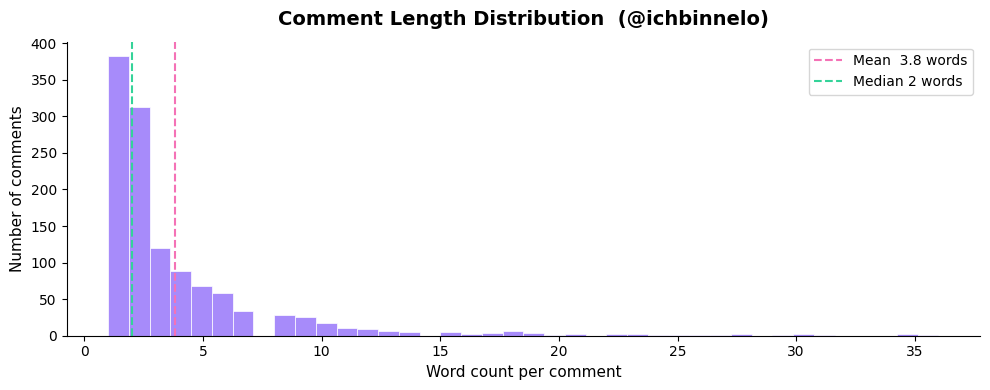

973 of 1211 comments (80%) are 5 words or fewer.
Longest comment: 36 words.


In [4]:
import matplotlib.pyplot as plt

word_counts = comments['comment_text'].dropna().apply(lambda x: len(str(x).split()))

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(word_counts[word_counts <= 40], bins=40, color='#a78bfa', edgecolor='white', linewidth=0.5)
ax.set_title('Comment Length Distribution  (@ichbinnelo)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Word count per comment', fontsize=11)
ax.set_ylabel('Number of comments',     fontsize=11)
ax.axvline(word_counts.mean(),   color='#f472b6', linestyle='--', linewidth=1.5, label=f'Mean  {word_counts.mean():.1f} words')
ax.axvline(word_counts.median(), color='#34d399', linestyle='--', linewidth=1.5, label=f'Median {word_counts.median():.0f} words')
ax.legend(fontsize=10)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('data/eda_comment_length.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'{(word_counts <= 5).sum()} of {len(word_counts)} comments ({(word_counts<=5).mean()*100:.0f}%) are 5 words or fewer.')
print(f'Longest comment: {word_counts.max()} words.')


## C4 — Top 20 most frequent terms

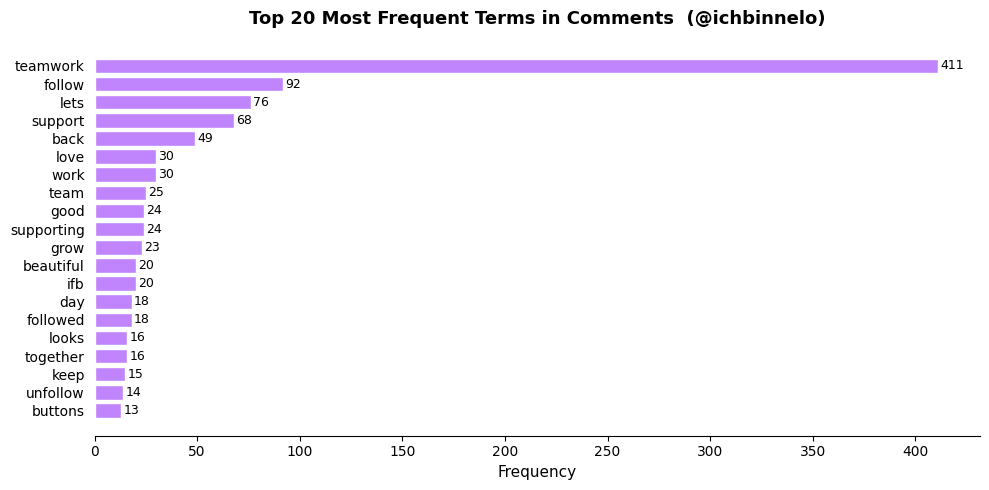

Top 20 terms:
  teamwork             411
  follow               92
  lets                 76
  support              68
  back                 49
  love                 30
  work                 30
  team                 25
  good                 24
  supporting           24
  grow                 23
  beautiful            20
  ifb                  20
  day                  18
  followed             18
  looks                16
  together             16
  keep                 15
  unfollow             14
  buttons              13


In [5]:
from collections import Counter
from nltk.corpus import stopwords
import matplotlib.pyplot as plt

STOPWORDS = set(stopwords.words('english')) | {
    'like','just','get','got','one','also','going','know','want',
    'lol','omg','im','ur','u','dont','cant','its','thats',
    'yes','hey','hi','ok','okay','done','haha','pls','plz',
}

all_tokens = []
for text in comments['comment_text'].dropna():
    tokens = [t for t in clean_text(str(text)).split() if t not in STOPWORDS and len(t) >= 3]
    all_tokens.extend(tokens)

top20 = Counter(all_tokens).most_common(20)
words, counts = zip(*top20)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(list(reversed(words)), list(reversed(counts)), color='#c084fc', edgecolor='white')
ax.set_title('Top 20 Most Frequent Terms in Comments  (@ichbinnelo)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Frequency', fontsize=11)
ax.spines[['top','right','left']].set_visible(False)
ax.tick_params(left=False)
for bar, count in zip(bars, reversed(counts)):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, str(count), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('data/eda_top_terms.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 20 terms:')
for word, count in top20:
    print(f'  {word:<20} {count}')


## C5 — Video type distribution

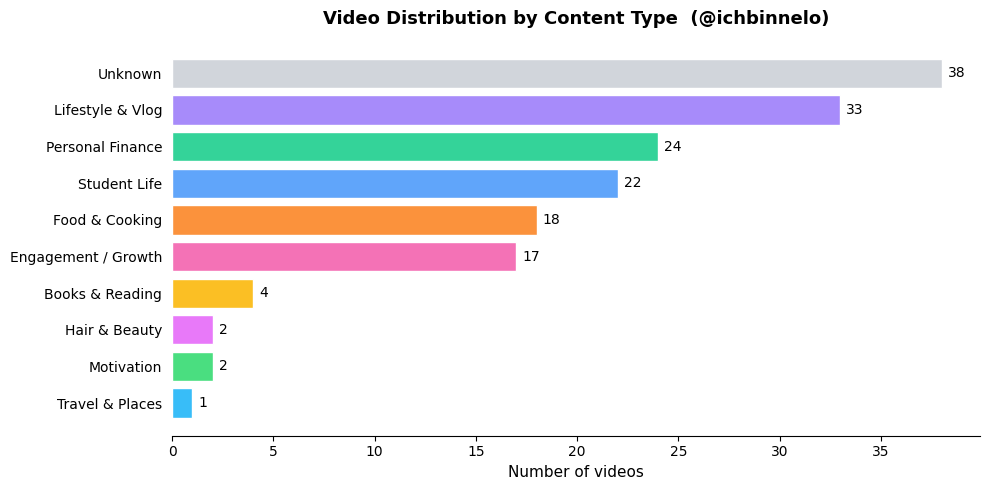

  Unknown                    38  (24%)
  Lifestyle & Vlog           33  (20%)
  Personal Finance           24  (15%)
  Student Life               22  (14%)
  Food & Cooking             18  (11%)
  Engagement / Growth        17  (11%)
  Books & Reading             4  (2%)
  Hair & Beauty               2  (1%)
  Motivation                  2  (1%)
  Travel & Places             1  (1%)


In [6]:
import matplotlib.pyplot as plt

type_counts = videos['video_type'].value_counts()

COLORS = {
    'Lifestyle & Vlog':    '#a78bfa', 'Unknown':             '#d1d5db',
    'Personal Finance':    '#34d399', 'Student Life':        '#60a5fa',
    'Food & Cooking':      '#fb923c', 'Engagement / Growth': '#f472b6',
    'Books & Reading':     '#fbbf24', 'Hair & Beauty':       '#e879f9',
    'Motivation':          '#4ade80', 'Travel & Places':     '#38bdf8',
}
colors = [COLORS.get(t, '#9ca3af') for t in type_counts.index]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(type_counts.index[::-1], type_counts.values[::-1], color=colors[::-1], edgecolor='white')
ax.set_title('Video Distribution by Content Type  (@ichbinnelo)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Number of videos', fontsize=11)
ax.spines[['top','right','left']].set_visible(False)
ax.tick_params(left=False)
for bar, val in zip(bars, type_counts.values[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=10)
plt.tight_layout()
plt.savefig('data/eda_video_types.png', dpi=150, bbox_inches='tight')
plt.show()

for vtype, count in type_counts.items():
    print(f'  {vtype:<25} {count:>3}  ({count/len(videos)*100:.0f}%)')


## C6 — Language breakdown

Detected as English     : 944 (78%)
Detected as non-English : 267 (22%)
(non-English comments were translated before NLP analysis)



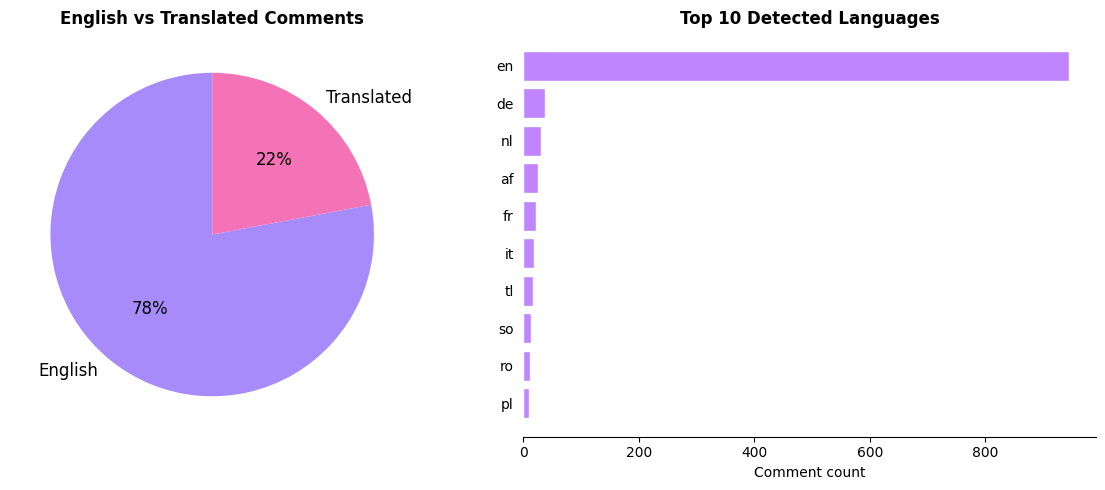

In [7]:
import matplotlib.pyplot as plt

lang_counts       = comments['language'].value_counts()
english_count     = lang_counts.get('en', 0)
non_english_count = len(comments) - english_count

print(f'Detected as English     : {english_count} ({english_count/len(comments)*100:.0f}%)')
print(f'Detected as non-English : {non_english_count} ({non_english_count/len(comments)*100:.0f}%)')
print('(non-English comments were translated before NLP analysis)')
print()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.pie([english_count, non_english_count], labels=['English','Translated'],
        colors=['#a78bfa','#f472b6'], autopct='%1.0f%%', startangle=90, textprops={'fontsize':12})
ax1.set_title('English vs Translated Comments', fontsize=12, fontweight='bold')

top10 = lang_counts.head(10)
ax2.barh(top10.index[::-1], top10.values[::-1], color='#c084fc', edgecolor='white')
ax2.set_title('Top 10 Detected Languages', fontsize=12, fontweight='bold')
ax2.set_xlabel('Comment count', fontsize=10)
ax2.spines[['top','right','left']].set_visible(False)
ax2.tick_params(left=False)

plt.tight_layout()
plt.savefig('data/eda_languages.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()
comment  = "I love this recipe, please make more!!"
score    = analyzer.polarity_scores(comment)['compound']
label    = "POSITIVE" if score >= 0.05 else "NEGATIVE" if score <= -0.05 else "NEUTRAL"

print(f"{score:+.3f}   {label}")

+0.795   POSITIVE


## C7 — VADER sentiment test

In [9]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def classify_sentiment(compound):
    if compound >= 0.05:  return 'POSITIVE'
    if compound <= -0.05: return 'NEGATIVE'
    return 'NEUTRAL'

sample_comments = [
    "omg I love this so much it looks amazing",
    "this is my favorite type of content please keep making these",
    "I wish you a wonderful day",
    "berlin is nice for tourists but not for residents",
    "what was the first thing in the video this one with strawberries looked delicious",
    "it is not such a bad winter day is it",
    "please do it because I am not that famous yet",
    "I have been trying to pay off my debt for years this really helped",
    "I add back everyone who adds me",
    "My condolences",
]

print(f'{"COMMENT":<55}  {"SCORE":>7}  LABEL')
print('-' * 80)
for comment in sample_comments:
    compound = analyzer.polarity_scores(comment)['compound']
    label    = classify_sentiment(compound)
    marker   = {'+': 'POSITIVE', '-': 'NEGATIVE', ' ': 'NEUTRAL'}
    print(f'{comment[:55]:<55}  {compound:>+.3f}  {label}')

print()
all_scores = comments['comment_text'].dropna().apply(
    lambda x: classify_sentiment(analyzer.polarity_scores(x)['compound'])
)
dist  = all_scores.value_counts()
total = len(all_scores)
print('Full corpus sentiment distribution:')
for label, count in dist.items():
    bar = '#' * int(count / total * 40)
    print(f'  {label:<10} {count:>5}  ({count/total*100:4.1f}%)  {bar}')


COMMENT                                                    SCORE  LABEL
--------------------------------------------------------------------------------
omg I love this so much it looks amazing                 +0.840  POSITIVE
this is my favorite type of content please keep making   +0.649  POSITIVE
I wish you a wonderful day                               +0.751  POSITIVE
berlin is nice for tourists but not for residents        +0.226  POSITIVE
what was the first thing in the video this one with str  +0.572  POSITIVE
it is not such a bad winter day is it                    +0.431  POSITIVE
please do it because I am not that famous yet            +0.318  POSITIVE
I have been trying to pay off my debt for years this re  -0.440  NEGATIVE
I add back everyone who adds me                          +0.000  NEUTRAL
My condolences                                           +0.000  NEUTRAL

Full corpus sentiment distribution:
  POSITIVE     723  (59.7%)  #######################
  NEUTRAL      433 

## Minimal Working Example — VADER Sentiment

In [10]:
# ── Minimal Working Example: Sentiment Classification ──────────────────────
# Input: raw comment text  →  Output: compound score + label
# Model: VADER (vaderSentiment, Hutto & Gilbert 2014)

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import pandas as pd

analyzer = SentimentIntensityAnalyzer()

def score(text):
    c = analyzer.polarity_scores(str(text))['compound']
    label = 'POSITIVE' if c >= 0.05 else ('NEGATIVE' if c <= -0.05 else 'NEUTRAL')
    return round(c, 3), label

# Run on 5 real comments from the dataset
comments = pd.read_csv('data/comments_20260526_233400.csv', encoding='utf-8-sig')
sample   = comments['comment_text'].dropna().sample(5, random_state=42).tolist()

print(f'{"COMMENT":<50}  {"SCORE":>7}  LABEL')
print('─' * 75)
for text in sample:
    compound, label = score(text)
    print(f'{str(text)[:50]:<50}  {compound:>+.3f}  {label}')


COMMENT                                               SCORE  LABEL
───────────────────────────────────────────────────────────────────────────
Wow yummy 😋 with my favorite song 🥹                 +0.881  POSITIVE
let's get this started 👍                            +0.000  NEUTRAL
Another day another lets go lets roll 😄👍🏻✨          +0.778  POSITIVE
nice routinee                                       +0.421  POSITIVE
Won’t unfollow                                      +0.000  NEUTRAL


## Minimal Working Example — TF-IDF Keyword Extraction

In [11]:
# ── Minimal Working Example: Keyword Extraction ─────────────────────────────
# Input: all comments for one video category  →  Output: top 10 keywords
# Model: TF-IDF (scikit-learn, unigrams + bigrams, English stopwords)

import re
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np

comments = pd.read_csv('data/comments_20260526_233400.csv', encoding='utf-8-sig')
videos   = pd.read_csv('data/videos_merged.csv',            encoding='utf-8-sig')

# Join so each comment inherits its video's category
merged = comments.merge(videos[['video_id','video_type']], on='video_id', how='left')

def clean(text):
    text = re.sub(r'[^a-zA-Z\s]', ' ', str(text).lower())
    return re.sub(r'\s+', ' ', text).strip()

# Extract keywords for one category — change this to explore others
CATEGORY = 'Food & Cooking'
corpus   = merged[merged['video_type'] == CATEGORY]['comment_text'].dropna().apply(clean).tolist()

vectorizer = TfidfVectorizer(max_features=200, stop_words='english',
                              ngram_range=(1, 2), min_df=2)
vectorizer.fit(corpus)

scores   = np.array(vectorizer.transform(corpus).mean(axis=0)).flatten()
top_idx  = scores.argsort()[::-1][:10]
keywords = [(vectorizer.get_feature_names_out()[i], round(scores[i], 4)) for i in top_idx]

print(f'Top 10 keywords — {CATEGORY}')
print('─' * 35)
for word, score in keywords:
    bar = '█' * int(score * 300)
    print(f'  {word:<22} {score:.4f}  {bar}')




Top 10 keywords — Food & Cooking
───────────────────────────────────
  yummy                  0.0966  ████████████████████████████
  looks                  0.0917  ███████████████████████████
  looks yummy            0.0455  █████████████
  thanks                 0.0416  ████████████
  think                  0.0416  ████████████
  just                   0.0416  ████████████
  love                   0.0387  ███████████
  bread                  0.0373  ███████████
  oh                     0.0373  ███████████
  fresh                  0.0373  ███████████


## Walking Skeleton — End-to-End Pipeline Proof

One pass through the real production modules (`nlp/`): load → preprocess →
sentiment → keywords → clustered output. This is the exact code path the
Streamlit app runs when a creator clicks **Run Analysis**.

In [12]:
import pandas as pd
from nlp.preprocessor import preprocess
from nlp.sentiment    import analyze_sentiment
from nlp.keywords     import extract_keywords, CLUSTER_LABELS

# ── STEP 1: Load raw scraped data ─────────────────────────────────────────────
print("STEP 1 - Loading raw data...")
df = pd.read_csv("data/comments_20260526_233400.csv", encoding="utf-8-sig")

# Align column names so the NLP modules can read them
df = df.rename(columns={"comment_text": "Comment Text", "language": "Comment Language"})
print(f"         {len(df)} comments loaded from @ichbinnelo")

# ── STEP 2: Preprocess ────────────────────────────────────────────────────────
print("\nSTEP 2 - Preprocessing...")
df_clean = preprocess(df)
print(f"         {len(df_clean)} comments remain after cleaning (English only, no noise)")

# ── STEP 3: Sentiment analysis ────────────────────────────────────────────────
print("\nSTEP 3 - Running sentiment analysis (VADER)...")
df_sentiment, summary = analyze_sentiment(df_clean)
print(f"         Positive : {summary['positive']}%")
print(f"         Neutral  : {summary['neutral']}%")
print(f"         Negative : {summary['negative']}%")

# ── STEP 4: Keyword extraction ────────────────────────────────────────────────
print("\nSTEP 4 - Extracting keywords (TF-IDF)...")
keywords, clusters = extract_keywords(df_sentiment, top_n=10)
print(f"         Top 5 keywords: {[w for w, _ in keywords[:5]]}")

# ── STEP 5: Output reaches the user ───────────────────────────────────────────
print("\n" + "=" * 50)
print("  ANALYSIS COMPLETE")
print("=" * 50)
print(f"  Comments analysed : {summary['total']}")
print(f"  Audience mood     : {summary['positive']}% positive")
print(f"  Top keyword       : {keywords[0][0] if keywords else 'n/a'}")
print()
print("  Keyword clusters:")
for cluster, words in clusters.items():
    if words:
        label = CLUSTER_LABELS[cluster]
        print(f"    {label:<25} : {', '.join(words[:3])}")
print("=" * 50)


STEP 1 - Loading raw data...
         1211 comments loaded from @ichbinnelo

STEP 2 - Preprocessing...
         944 comments remain after cleaning (English only, no noise)

STEP 3 - Running sentiment analysis (VADER)...
         Positive : 24.5%
         Neutral  : 73.7%
         Negative : 1.8%

STEP 4 - Extracting keywords (TF-IDF)...
         Top 5 keywords: ['teamwork', 'support', 'follow', 'lets', 'love']

  ANALYSIS COMPLETE
  Comments analysed : 944
  Audience mood     : 24.5% positive
  Top keyword       : teamwork

  Keyword clusters:
    Positive Reactions        : love
    General Engagement        : teamwork, support, follow


## Niche Performance & Audience Requests
### (the analytics behind the Recommendations page)

Two further modules turn the NLP outputs into creator advice — both are pure
pandas / regex, **no ML**:

- `nlp/niche_analyzer.py` — per-content-type statistics from the joined
  comments + video metadata: comments per video, average views, discussion
  per 1,000 views, sentiment share, ranked comparison.
- `nlp/request_extractor.py` — pattern matching for explicit audience asks
  ("teach me X", "how much does X cost", "recipe please"), grouped and
  counted with the content type they come from.

Every recommendation card in the app cites numbers produced by these two
modules — nothing on that page is generated by a model.

In [ ]:
import sys
import pandas as pd
sys.path.insert(0, '.')

from nlp.preprocessor import preprocess
from nlp.sentiment import analyze_sentiment
from nlp.niche_analyzer import analyze_niches
from nlp.request_extractor import extract_requests
from app.components.upload import normalize_comment_columns, merge_video_metadata

comments = normalize_comment_columns(
    pd.read_csv('data/comments_20260526_233400.csv', encoding='utf-8-sig'))
videos = pd.read_csv('data/videos_merged.csv', encoding='utf-8-sig')

merged, n_matched = merge_video_metadata(comments, videos)
analyzed, _ = analyze_sentiment(preprocess(merged))
print(f'{n_matched} comments matched to video metadata\n')

# ── Niche performance ────────────────────────────────────────────────────────
na = analyze_niches(analyzed, videos)
print('Niche ranking (by comments per video):')
print(f'  {"niche":<22} {"com/vid":>8} {"avg views":>10} {"disc/1k":>8} {"pos%":>6}')
for t in na['ranked'][:6]:
    m = na['niches'][t]
    views = f'{m["avg_views"]:,.0f}' if m['avg_views'] else '-'
    disc  = m['discussion_per_1k'] if m['discussion_per_1k'] is not None else '-'
    print(f'  {t:<22} {m["comments_per_video"]:>8} {views:>10} {str(disc):>8} {m["positive_pct"]:>6}')

print(f'\nBest niche : {na["best"]}  '
      f'({na["engagement_ratio"]}x the engagement of {na["weakest"]})')

# ── Audience requests ────────────────────────────────────────────────────────
print('\nTop audience requests (pattern-extracted, grouped, counted):')
for r in extract_requests(analyzed)[:5]:
    where = f'  [{r["top_video_type"]}]' if r['top_video_type'] else ''
    print(f'  {r["count"]:>3}x  "{r["request"]}"{where}')

---

## Deliverable 8 — Evaluation & Quality

This section measures how well the **current** pipeline performs, compares it
against two baselines, and identifies where it fails. Results match the
README (section S8) and `evaluation.py`.

| Sub-section | What it measures |
|---|---|
| **Sections 1 + 2** | Accuracy & Macro F1 on a 37-comment held-out test set; naive baseline vs ablation vs full system |
| **Section 3** | Full six-stage pipeline latency, throughput, cost per query, bottleneck |
| **Section 4** | Categorised failure modes with counts, examples, and prioritized fixes |
| **Section 5** | User study results: SUS 87.5 (A+), 100% task success, findings, quotes |

### Sections 1 & 2: Performance Metrics + Benchmark Comparison

**Ground truth:** `data/test_set_labels.csv` — 37 real comments from
`@ichbinnelo` (20 positive / 15 neutral / 2 negative). The labels were
**initialised with TextBlob** (an independent algorithm, so no circular logic
with VADER) and then **manually reviewed**. This cell *loads* the file — it
never regenerates it — so the results are reproducible and the ground truth
is stable.

The set is held-out in the strict sense: nothing in the pipeline is trained,
and these labels were never used to tune any threshold or preprocessing
decision.

**Three systems compared on the same test set:**

| System | Description |
|---|---|
| **Baseline A (naive)** | Majority class — always predicts "positive" (no NLP at all) |
| **Baseline B (ablation)** | VADER on cleaned text — emojis/caps/punctuation stripped (the system *without* its key design decision) |
| **Full system** | VADER on original text — emoji-aware (what the app ships) |

**Why these metrics?**
- **Accuracy** — overall correctness; the test set mirrors the real class balance
- **Macro F1** — weights each class equally, so the rare negative class (the high-value one for creators) counts as much as the dominant positive class

In [ ]:
import sys
import pandas as pd
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.metrics import accuracy_score, f1_score, classification_report

sys.path.insert(0, '.')
from nlp.preprocessor import clean_text

nltk.download('vader_lexicon', quiet=True)
sia = SentimentIntensityAnalyzer()

def classify(compound):
    if compound >= 0.05:  return 'positive'
    if compound <= -0.05: return 'negative'
    return 'neutral'

# Load the reviewed held-out test set (never regenerated here)
test   = pd.read_csv('data/test_set_labels.csv', encoding='utf-8-sig')
y_true = test['true_label'].str.strip().str.lower().tolist()
labels = sorted(set(y_true))

# Baseline A: majority class (no NLP)
majority = pd.Series(y_true).mode()[0]
y_naive  = [majority] * len(test)

# Baseline B (ablation): VADER on cleaned text - emojis stripped
y_ablat = [classify(sia.polarity_scores(clean_text(t))['compound'])
           if len(clean_text(t)) >= 3 else 'neutral'
           for t in test['Comment Text']]

# Full system: VADER on original text (exactly what nlp/sentiment.py does)
y_full = [classify(sia.polarity_scores(str(t))['compound'])
          for t in test['Comment Text']]

def scores(y_pred):
    return (round(accuracy_score(y_true, y_pred) * 100, 1),
            round(f1_score(y_true, y_pred, average='macro',
                           zero_division=0, labels=labels) * 100, 1))

rows = [(f'Baseline A: majority class (always "{majority}")', *scores(y_naive)),
        ('Baseline B: VADER on cleaned text (emojis stripped)', *scores(y_ablat)),
        ('Full system: VADER on original text (emoji-aware)',  *scores(y_full))]

print(f'Test set: {len(test)} comments | classes: '
      + ', '.join(f'{c}={y_true.count(c)}' for c in labels))
print(f'\n{"System":<55} {"Accuracy":>9} {"Macro F1":>9}')
print('-' * 76)
for name, acc, f1 in rows:
    print(f'{name:<55} {acc:>8}% {f1:>8}%')

acc_a, f1_a = rows[0][1], rows[0][2]
acc_b, f1_b = rows[1][1], rows[1][2]
acc_f, f1_f = rows[2][1], rows[2][2]
print(f'\nGain over naive baseline : +{round(acc_f-acc_a,1)} pts accuracy, '
      f'+{round(f1_f-f1_a,1)} pts Macro F1')
print(f'Gain from keeping emojis : +{round(acc_f-acc_b,1)} pts accuracy, '
      f'+{round(f1_f-f1_b,1)} pts Macro F1')
print('\nInsight: stripping emojis/caps/punctuation removes exactly the signals')
print('VADER was built to read. On TikTok, the emoji often IS the sentiment.')
print('\nClassification report - full system vs reviewed labels:')
print(classification_report(y_true, y_full, labels=labels, zero_division=0))

test['pred_full'] = y_full  # reused by the error analysis below

### Section 3: Pipeline Efficiency Test

Times the **full six-stage pipeline** — video merge → preprocess → sentiment →
keywords → niche analysis → request extraction — on the real dataset
(1,211 comments + 161 videos), 10 runs, with a per-stage bottleneck breakdown.

Cost is **EUR 0.00 per query at every scale**: the pipeline is fully local
(lexicon + statistics), no API calls, no GPU. TikTok scraping (~55 min for
161 videos) is a one-time data-collection step, separate from the analysis.

In [ ]:
import sys, time
import numpy as np
import pandas as pd
sys.path.insert(0, '.')

from nlp.preprocessor import preprocess
from nlp.sentiment import analyze_sentiment
from nlp.keywords import extract_keywords
from nlp.niche_analyzer import analyze_niches
from nlp.request_extractor import extract_requests
from app.components.upload import normalize_comment_columns, merge_video_metadata

raw    = normalize_comment_columns(
            pd.read_csv('data/comments_20260526_233400.csv', encoding='utf-8-sig'))
videos = pd.read_csv('data/videos_merged.csv', encoding='utf-8-sig')

stages = {s: [] for s in ['merge', 'preprocess', 'sentiment',
                          'keywords', 'niche', 'requests']}
totals = []
for _ in range(10):
    df = raw.copy(); t0 = time.perf_counter()
    t = time.perf_counter(); df, _ = merge_video_metadata(df, videos)
    stages['merge'].append(time.perf_counter() - t)
    t = time.perf_counter(); dfc = preprocess(df)
    stages['preprocess'].append(time.perf_counter() - t)
    t = time.perf_counter(); dfa, _ = analyze_sentiment(dfc)
    stages['sentiment'].append(time.perf_counter() - t)
    t = time.perf_counter(); extract_keywords(dfa, top_n=20)
    stages['keywords'].append(time.perf_counter() - t)
    t = time.perf_counter(); analyze_niches(dfa, videos)
    stages['niche'].append(time.perf_counter() - t)
    t = time.perf_counter(); extract_requests(dfa)
    stages['requests'].append(time.perf_counter() - t)
    totals.append(time.perf_counter() - t0)

mean_s, worst_s = float(np.mean(totals)), float(np.max(totals))

print(f'{len(raw)} comments + {len(videos)} videos | 10 full runs of all 6 stages\n')
print(f'  Mean latency : {mean_s:.2f} s')
print(f'  Worst case   : {worst_s:.2f} s')
print(f'  Throughput   : {len(raw)/mean_s:,.0f} comments/second end-to-end\n')

print(f'{"Scale":<22} {"Avg Latency":>12} {"Worst Case":>11} {"Cost/Query":>11} {"Est. Monthly":>13}')
print('-' * 74)
for label in ['100 queries/mo', '1,000 queries/mo', '10,000 queries/mo']:
    print(f'{label:<22} {f"{mean_s:.2f} s":>12} {f"{worst_s:.2f} s":>11} '
          f'{"EUR 0.00":>11} {"EUR 0.00":>13}')

print('\nPer-stage breakdown (mean):')
for s, v in sorted(stages.items(), key=lambda kv: -np.mean(kv[1])):
    print(f'  {s:<11} {np.mean(v)*1000:>6.0f} ms  ({np.mean(v)/mean_s*100:>3.0f}%)')

bottleneck = max(stages, key=lambda k: np.mean(stages[k]))
print(f'\nBottleneck : {bottleneck} '
      f'({np.mean(stages[bottleneck])/mean_s*100:.0f}% of total latency)')
print('Cost       : EUR 0.00 - fully local, no API calls')
print('Note       : TikTok scraping (~55 min for 161 videos) is one-time data')
print('             collection, separate from the analysis pipeline')

### Section 4: Error Analysis (current system)

Failure modes of the **current** pipeline with counts, root causes, and
concrete examples.

Note on history: the emoji-only failure (147 comments, 12.1% of data) was
found by an earlier round of this analysis and is now **FIXED** — VADER
scores the *original* text, so emoji-only comments are kept and scored.
The ablation in Section 2 quantifies the value of that fix (+5.4 pts
accuracy, +9.8 pts Macro F1).

*Run Sections 1 & 2 first — this cell reuses `test`, `sia` and `classify`.*

In [ ]:
import pandas as pd

raw = normalize_comment_columns(
        pd.read_csv('data/comments_20260526_233400.csv', encoding='utf-8-sig'))
n = len(raw)

# 1. Non-English exclusion (incl. likely langdetect false positives)
non_en = raw[raw['Comment Language'].str.lower() != 'en']
short_non_en = non_en[non_en['Comment Text'].fillna('').str.split().str.len() <= 2]

# 2. Hype slang scored negative (VADER lexicon predates Gen-Z usage)
slang = ['hard', 'crazy', 'sick', 'insane', 'dead', 'killed', 'brutal']
en = raw[raw['Comment Language'].str.lower() == 'en']
slang_rows = en[en['Comment Text'].str.lower().str.contains(
    '|'.join(rf'\b{s}\b' for s in slang), na=False)]
slang_neg = sum(1 for t in slang_rows['Comment Text']
                if classify(sia.polarity_scores(str(t))['compound']) == 'negative')

# 3. Misclassifications on the labelled test set (from Sections 1 & 2)
wrong = test[test['true_label'].str.strip().str.lower() != test['pred_full']]

# 4. Sarcasm risk: marker words + confident positive score
markers = ['lol', 'haha', 'sure', 'obviously']
marked = en[en['Comment Text'].str.lower().str.contains('|'.join(markers), na=False)]
sarcasm = sum(1 for t in marked['Comment Text']
              if sia.polarity_scores(str(t))['compound'] > 0.3)

print(f'{"Error category":<46} {"Count":>12} {"Priority":>9}')
print('-' * 70)
print(f'{"Non-English comments excluded":<46} {f"{len(non_en)}/{n}":>12} {"HIGH":>9}')
print(f'{"  ...likely langdetect false positives":<46} '
      f'{f"{len(short_non_en)}/{len(non_en)}":>12} {"HIGH":>9}')
print(f'{"Test-set misclassifications":<46} {f"{len(wrong)}/{len(test)}":>12} {"MEDIUM":>9}')
print(f'{"Hype slang scored negative":<46} {f"{slang_neg}/{len(slang_rows)}":>12} {"MEDIUM":>9}')
print(f'{"Potential sarcasm scored positive":<46} {f"{sarcasm}/{n}":>12} {"LOW":>9}')

print('\nConcrete misclassified examples (full system vs reviewed label):')
for _, r in wrong.head(3).iterrows():
    print(f'  "{str(r["Comment Text"])[:58]}" '
          f'- labelled {r["true_label"].strip().lower()}, predicted {r["pred_full"]}')

print('''
Root causes:
  Non-English : only German was translated at scrape time; the rest is
                dropped - but most flagged rows are 1-2 word English
                comments ("wow") that langdetect misreads as other languages
  Boundary    : all test-set errors sit at the neutral/positive boundary
                (the +/-0.05 compound threshold)
  Slang       : VADER lexicon predates Gen-Z usage of hard/crazy/sick as praise
  Sarcasm     : a lexicon cannot read tone

Top fixes (priority order):
  1. [HIGH]   Trust short ASCII-only comments as English instead of dropping
              them on langdetect's guess - recovers ~142 comments, zero risk
  2. [MEDIUM] Custom VADER lexicon entries for TikTok hype slang
  3. [LOW]    Flag sarcasm-marker comments for review, or swap to
              cardiffnlp/twitter-roberta-base-sentiment''')

### Section 5: User Evaluation — Results

Structured study with **real target users**: small TikTok creators
(under 500 to 2,000 followers), each testing on a personalised dataset
(comments + videos CSV) via a 6-task guide, followed by a questionnaire
and the standard 10-item SUS.

| Measure | Result |
|---|---|
| **SUS score** | **87.5 / 100 — Grade A+** (n = 6; Sauro–Lewis scale; industry avg = 68) |
| Task success rate | 100% (4/4 completed register → two-file upload → analysis without help) |
| "The analysis felt true" | 3.0 / 5 |
| Would use the app | 50% yes, 50% maybe, 0% no |

Individual SUS scores: 80, 82.5, 85, 85, 92.5, 100
(odd items: answer − 1; even items: 5 − answer; sum × 2.5).

**Top 3 usability findings:**
1. *Keyword clusters feel opaque* — testers want to see **why** a word was
   categorized, not just the word (planned fix: explainable clusters).
2. *Slang scored negative* — a music creator independently hit the documented
   VADER limitation from Section 4: the error analysis predicted a real
   user-facing failure before a user found it.
3. *Demand for real data* — 3 of 4 testers asked to run the analysis on their
   own comment sections (a user-accessible scraping path). Strong product
   validation.

**User quotes:**
> "An app that scrapes through your TikTok comments, categorizes them
> according to their positivity and gives you suggestions on future videos
> based on users requests."

> "The way it grades the comments, it makes u know if your contents are
> really engaging and encourages you to do more, it also gives u an insight
> of what to create."

**Fix loop confirmed by users:** tester 2 (Wudh) found the recommendations
generic — caused by the "content" keyword bug identified in error analysis;
after filtering generic platform words and rebuilding recommendations to cite
measured evidence, no later tester reported the issue.